# Document Type Recognition on MIDV-500

<a href="https://colab.research.google.com/github/<your-username>/document-type-recognition/blob/main/document_type_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classification of 50 identity document types from the MIDV-500 dataset with a fine-tuned ResNet18. See the README for details.

> On Colab select a GPU runtime first: *Runtime -> Change runtime type -> T4 GPU*.

In [ ]:
!pip install midv500
!pip uninstall -y albumentations albumentationsx albucore
!pip install "numpy<2.3" "albumentations==2.0.8"

In [4]:
import midv500
import cv2
import albumentations as A
from pathlib import Path
from sklearn.model_selection import train_test_split

In [ ]:
dataset_dir = 'data/raw/'
dataset_name = "midv500"
midv500.download_dataset(dataset_dir, dataset_name)

In [4]:
midv500_dir = Path(dataset_dir) / dataset_name
doc_type_images_dirs = sorted([folder / "images" for folder in midv500_dir.rglob("*") if folder.is_dir() and folder.parent == midv500_dir])
print("Numero cartelle:", len(doc_type_images_dirs))
print("Cartelle:", doc_type_images_dirs)

Numero cartelle: 50
Cartelle: [PosixPath('/content/data/raw/midv500/01_alb_id/images'), PosixPath('/content/data/raw/midv500/02_aut_drvlic_new/images'), PosixPath('/content/data/raw/midv500/03_aut_id_old/images'), PosixPath('/content/data/raw/midv500/04_aut_id/images'), PosixPath('/content/data/raw/midv500/05_aze_passport/images'), PosixPath('/content/data/raw/midv500/06_bra_passport/images'), PosixPath('/content/data/raw/midv500/07_chl_id/images'), PosixPath('/content/data/raw/midv500/08_chn_homereturn/images'), PosixPath('/content/data/raw/midv500/09_chn_id/images'), PosixPath('/content/data/raw/midv500/10_cze_id/images'), PosixPath('/content/data/raw/midv500/11_cze_passport/images'), PosixPath('/content/data/raw/midv500/12_deu_drvlic_new/images'), PosixPath('/content/data/raw/midv500/13_deu_drvlic_old/images'), PosixPath('/content/data/raw/midv500/14_deu_id_new/images'), PosixPath('/content/data/raw/midv500/15_deu_id_old/images'), PosixPath('/content/data/raw/midv500/16_deu_passport

In [5]:
def obtain_sets(random_state=None):
    videos = [
        "CA", "CS", "HA", "HS", "KA",
        "KS", "PA", "PS", "TA", "TS"
    ]
    train_videos, temp_videos = train_test_split(
        videos,
        test_size=0.30,
        shuffle=True,
        random_state=random_state
    )
    val_videos, test_videos = train_test_split(
        temp_videos,
        test_size=1/3,
        shuffle=True,
        random_state=random_state
    )
    return train_videos, val_videos, test_videos

train_set = []
val_set = []
test_set = []

for i, doc_type_images_dir in enumerate(doc_type_images_dirs):
  video_dirs = [video_dir for video_dir in doc_type_images_dir.rglob("*") if video_dir.is_dir() and video_dir.parent == doc_type_images_dir]

  train_videos, val_videos, test_videos = obtain_sets(random_state = 42 + i)

  for video_dir in video_dirs:
    if video_dir.name in train_videos:
      train_set += list(video_dir.glob("*.tif"))
    elif video_dir.name in val_videos:
      val_set += list(video_dir.glob("*.tif"))
    elif video_dir.name in test_videos:
      test_set += list(video_dir.glob("*.tif"))
    else:
      print("Errore:", video_dir.name)

print(
    "TRAIN SET:", len(train_set),
    "TRAIN corretto:", len(train_set) == 50 * 7 * 30
)
print(
    "VALIDATION SET:", len(val_set),
    "VALIDATION corretto:", len(val_set) == 50 * 2 * 30
)
print(
    "TEST SET:", len(test_set),
    "TEST corretto:", len(test_set) == 50 * 1 * 30
)
print(
    "TOTAL:",
    len(train_set) + len(val_set) + len(test_set),
    "TOTAL corretto:",
    len(train_set) + len(val_set) + len(test_set) == 50 * 10 * 30
)

train_videos_all = set()
val_videos_all = set()
test_videos_all = set()

for image in train_set:
    train_videos_all.add(image.parent)
for image in val_set:
    val_videos_all.add(image.parent)
for image in test_set:
    test_videos_all.add(image.parent)

print("Train ∩ Validation:",
      train_videos_all & val_videos_all)
print("Train ∩ Test:",
      train_videos_all & test_videos_all)
print("Validation ∩ Test:",
      val_videos_all & test_videos_all)

TRAIN SET: 10500 TRAIN corretto: True
VALIDATION SET: 3000 VALIDATION corretto: True
TEST SET: 1500 TEST corretto: True
TOTAL: 15000 TOTAL corretto: True
Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()


# Document type Recognition

In [6]:
import os
import json
import torch
import numpy as np
from albumentations.pytorch import ToTensorV2
from collections import Counter
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import models
from torch import nn

In [7]:
class_to_idx = dict([(doc_type.parent.name, i) for i, doc_type in enumerate(doc_type_images_dirs)])

def append_label(ds, class_to_idx):
  return [(path, class_to_idx[path.parents[2].name]) for path in ds]

train_ds = append_label(train_set, class_to_idx)
val_ds = append_label(val_set, class_to_idx)
test_ds = append_label(test_set, class_to_idx)

res_train_count = Counter([label for path, label in train_ds])
print(min(res_train_count.values()), max(res_train_count.values()))
res_val_count = Counter([label for path, label in val_ds])
print(min(res_val_count.values()), max(res_val_count.values()))
res_test_count = Counter([label for path, label in test_ds])
print(min(res_test_count.values()), max(res_test_count.values()))

210 210
60 60
30 30


In [10]:
def rectify(frame_path):
  base = frame_path.parents[2]

  # Frame
  frame = cv2.imread(str(frame_path))

  # Immagine di riferimento
  reference_path = frame_path.parents[2] / "images" / f"{base.name}.tif"
  reference = cv2.imread(str(reference_path))

  # Ground truth del frame
  current_video = '/'.join(frame_path.parts[-2:]).removesuffix('.tif')

  gt_frame_path = base / f"ground_truth/{current_video}.json"

  with open(gt_frame_path, "r") as f:
      gt_frame = json.load(f)

  frame_quad = np.array(gt_frame["quad"], dtype=np.float32)

  # Dimensioni dell'immagine di riferimento
  h_ref, w_ref = reference.shape[:2]

  reference_quad = np.array([
      [0, 0],
      [w_ref - 1, 0],
      [w_ref - 1, h_ref - 1],
      [0, h_ref - 1]
  ], dtype=np.float32)

  # Omografia
  H = cv2.getPerspectiveTransform(frame_quad, reference_quad)

  # Rettifica
  rectified = cv2.warpPerspective(
      frame,
      H,
      (w_ref, h_ref)
  )

  return rectified

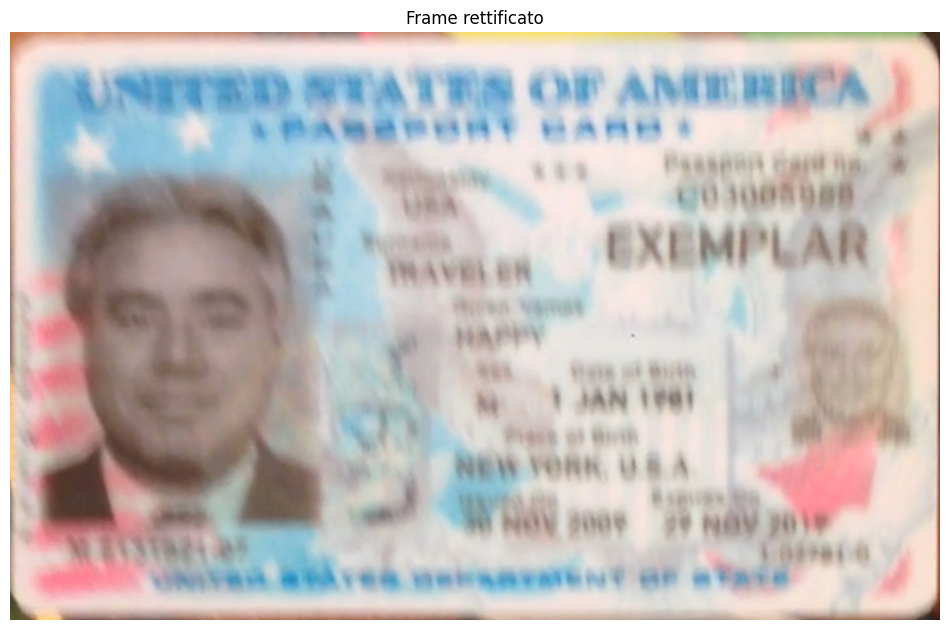

In [11]:
import matplotlib.pyplot as plt

rectified = rectify(train_ds[10000][0])

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(rectified, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Frame rettificato")
plt.show()

In [12]:
class DocTypeDataset(Dataset):
  def __init__(self, labeled_paths, transform) -> None:
    self.ds = labeled_paths
    self.transform = transform

  def __len__(self) -> int:
    return len(self.ds)

  def __getitem__(self, index) -> tuple:
     path, label = self.ds[index]
     image_rectified = rectify(path)
     image_rgb = cv2.cvtColor(image_rectified, cv2.COLOR_BGR2RGB)
     image_trasformed = self.transform(image=image_rgb)["image"]
     return image_trasformed, label


In [13]:
train_transform = A.Compose([
    A.Resize(224, 224),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 9), p=1.0),
        A.MotionBlur(blur_limit=(3, 9), p=1.0),
    ], p=0.3),
    A.Perspective(scale=(0.02, 0.08), p=0.3),
    A.Affine(rotate=(-10, 10), shear=(-5, 5), border_mode=cv2.BORDER_REFLECT, p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # Pesi specifici di ResNet18
    ToTensorV2(),
])

train_dataset = DocTypeDataset(train_ds, transform=train_transform)
val_dataset = DocTypeDataset(val_ds, transform=eval_transform)
test_dataset = DocTypeDataset(test_ds, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [14]:
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

True


In [15]:
resnet = models.resnet18(weights="IMAGENET1K_V1")

num_classes = len(class_to_idx)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes) # in_features: 512, num_classes: 50
print(resnet.fc)

resnet = resnet.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


Linear(in_features=512, out_features=50, bias=True)


In [16]:
for param in resnet.parameters():
  param.requires_grad = False
for param in resnet.fc.parameters():
  param.requires_grad = True

# Questo ciclo scorre tutti i parametri del modello (con il loro nome, tipo "fc.weight", "layer1.0.conv1.weight", ecc.)
# e stampa solo quelli che hai lasciato "allenabili" (cioè requires_grad=True).
# Se hai fatto tutto correttamente nei due cicli di prima, dovresti vedere solo due righe: fc.weight e fc.bias.
for name, param in resnet.named_parameters():
    if param.requires_grad:
        print(name)

fc.weight
fc.bias


In [17]:
trainable_params = [p for p in resnet.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=1e-3)

In [18]:
criterion = nn.CrossEntropyLoss()

In [19]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            output = model(images)
            loss = criterion(output, labels)

            preds = torch.argmax(output, dim=1)
            total_loss += loss.item() * images.size(0)
            total_correct += torch.sum(preds == labels).item()
            total_samples += images.size(0)

    epoch_loss = total_loss / total_samples
    epoch_accuracy = total_correct / total_samples
    return epoch_loss, epoch_accuracy

In [20]:
os.makedirs("checkpoints", exist_ok=True)

In [21]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        preds = torch.argmax(output, dim=1)
        total_loss += loss.item() * images.size(0)
        total_correct += torch.sum(preds == labels).item()
        total_samples += images.size(0)

    epoch_loss = total_loss / total_samples
    epoch_accuracy = total_correct / total_samples
    return epoch_loss, epoch_accuracy


N_EPOCHS = 5
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_one_epoch(resnet, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(resnet, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{N_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
          f"gap={train_acc - val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save(resnet.state_dict(), "checkpoints/doc_type_rec_model.pth")

        print(f"Saved best model, val_acc={val_acc:.4f}")

Epoch 1/5 | train_loss=1.2563 train_acc=0.8135 | val_loss=0.3237 val_acc=0.9500 | gap=-0.1365
Saved best model, val_acc=0.9500
Epoch 2/5 | train_loss=0.3401 train_acc=0.9469 | val_loss=0.2435 val_acc=0.9553 | gap=-0.0085
Saved best model, val_acc=0.9553
Epoch 3/5 | train_loss=0.2490 train_acc=0.9549 | val_loss=0.2326 val_acc=0.9553 | gap=-0.0005
Epoch 4/5 | train_loss=0.2097 train_acc=0.9585 | val_loss=0.2150 val_acc=0.9613 | gap=-0.0029
Saved best model, val_acc=0.9613
Epoch 5/5 | train_loss=0.1815 train_acc=0.9638 | val_loss=0.2131 val_acc=0.9610 | gap=0.0028


 # Test

In [22]:
doc_type_rec_model = models.resnet18(weights=None)
doc_type_rec_model.fc = nn.Linear(doc_type_rec_model.fc.in_features, len(class_to_idx))


state_dict = torch.load(
    "checkpoints/doc_type_rec_model.pth",
    map_location=device
)

doc_type_rec_model.load_state_dict(state_dict)
doc_type_rec_model = doc_type_rec_model.to(device)
doc_type_rec_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [26]:
total_correct = 0
total_samples = 0

all_preds = []
all_labels = []

with torch.no_grad():
  # torch.no_grad è importante perchè durante il test non devi calcolare i gradienti:
  # riduce il consumo di memoria e rende l'inferenza più efficiente.
  for images, labels in test_loader:

    images = images.to(device)
    labels = labels.to(device)

    output = doc_type_rec_model(images)

    preds = torch.argmax(output, dim = 1)

    total_correct += torch.sum(preds == labels).item()
    total_samples += images.size(0)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

test_acc = total_correct / total_samples
print(f"test_acc={test_acc:.4f}")

test_acc=0.9673


# Evaluation

In [27]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# F1
macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

print(f"Macro F1:    {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

# F1, precision, recall e support per ogni classe
print(classification_report(
    all_labels,
    all_preds,
    target_names=list(class_to_idx.keys())
))

Macro F1:    0.9665
Weighted F1: 0.9665
                         precision    recall  f1-score   support

              01_alb_id       0.91      1.00      0.95        30
      02_aut_drvlic_new       1.00      1.00      1.00        30
          03_aut_id_old       1.00      1.00      1.00        30
              04_aut_id       0.81      1.00      0.90        30
        05_aze_passport       1.00      0.73      0.85        30
        06_bra_passport       0.97      1.00      0.98        30
              07_chl_id       1.00      1.00      1.00        30
      08_chn_homereturn       0.86      1.00      0.92        30
              09_chn_id       1.00      1.00      1.00        30
              10_cze_id       0.88      0.97      0.92        30
        11_cze_passport       1.00      1.00      1.00        30
      12_deu_drvlic_new       1.00      1.00      1.00        30
      13_deu_drvlic_old       1.00      1.00      1.00        30
          14_deu_id_new       0.94      1.00     

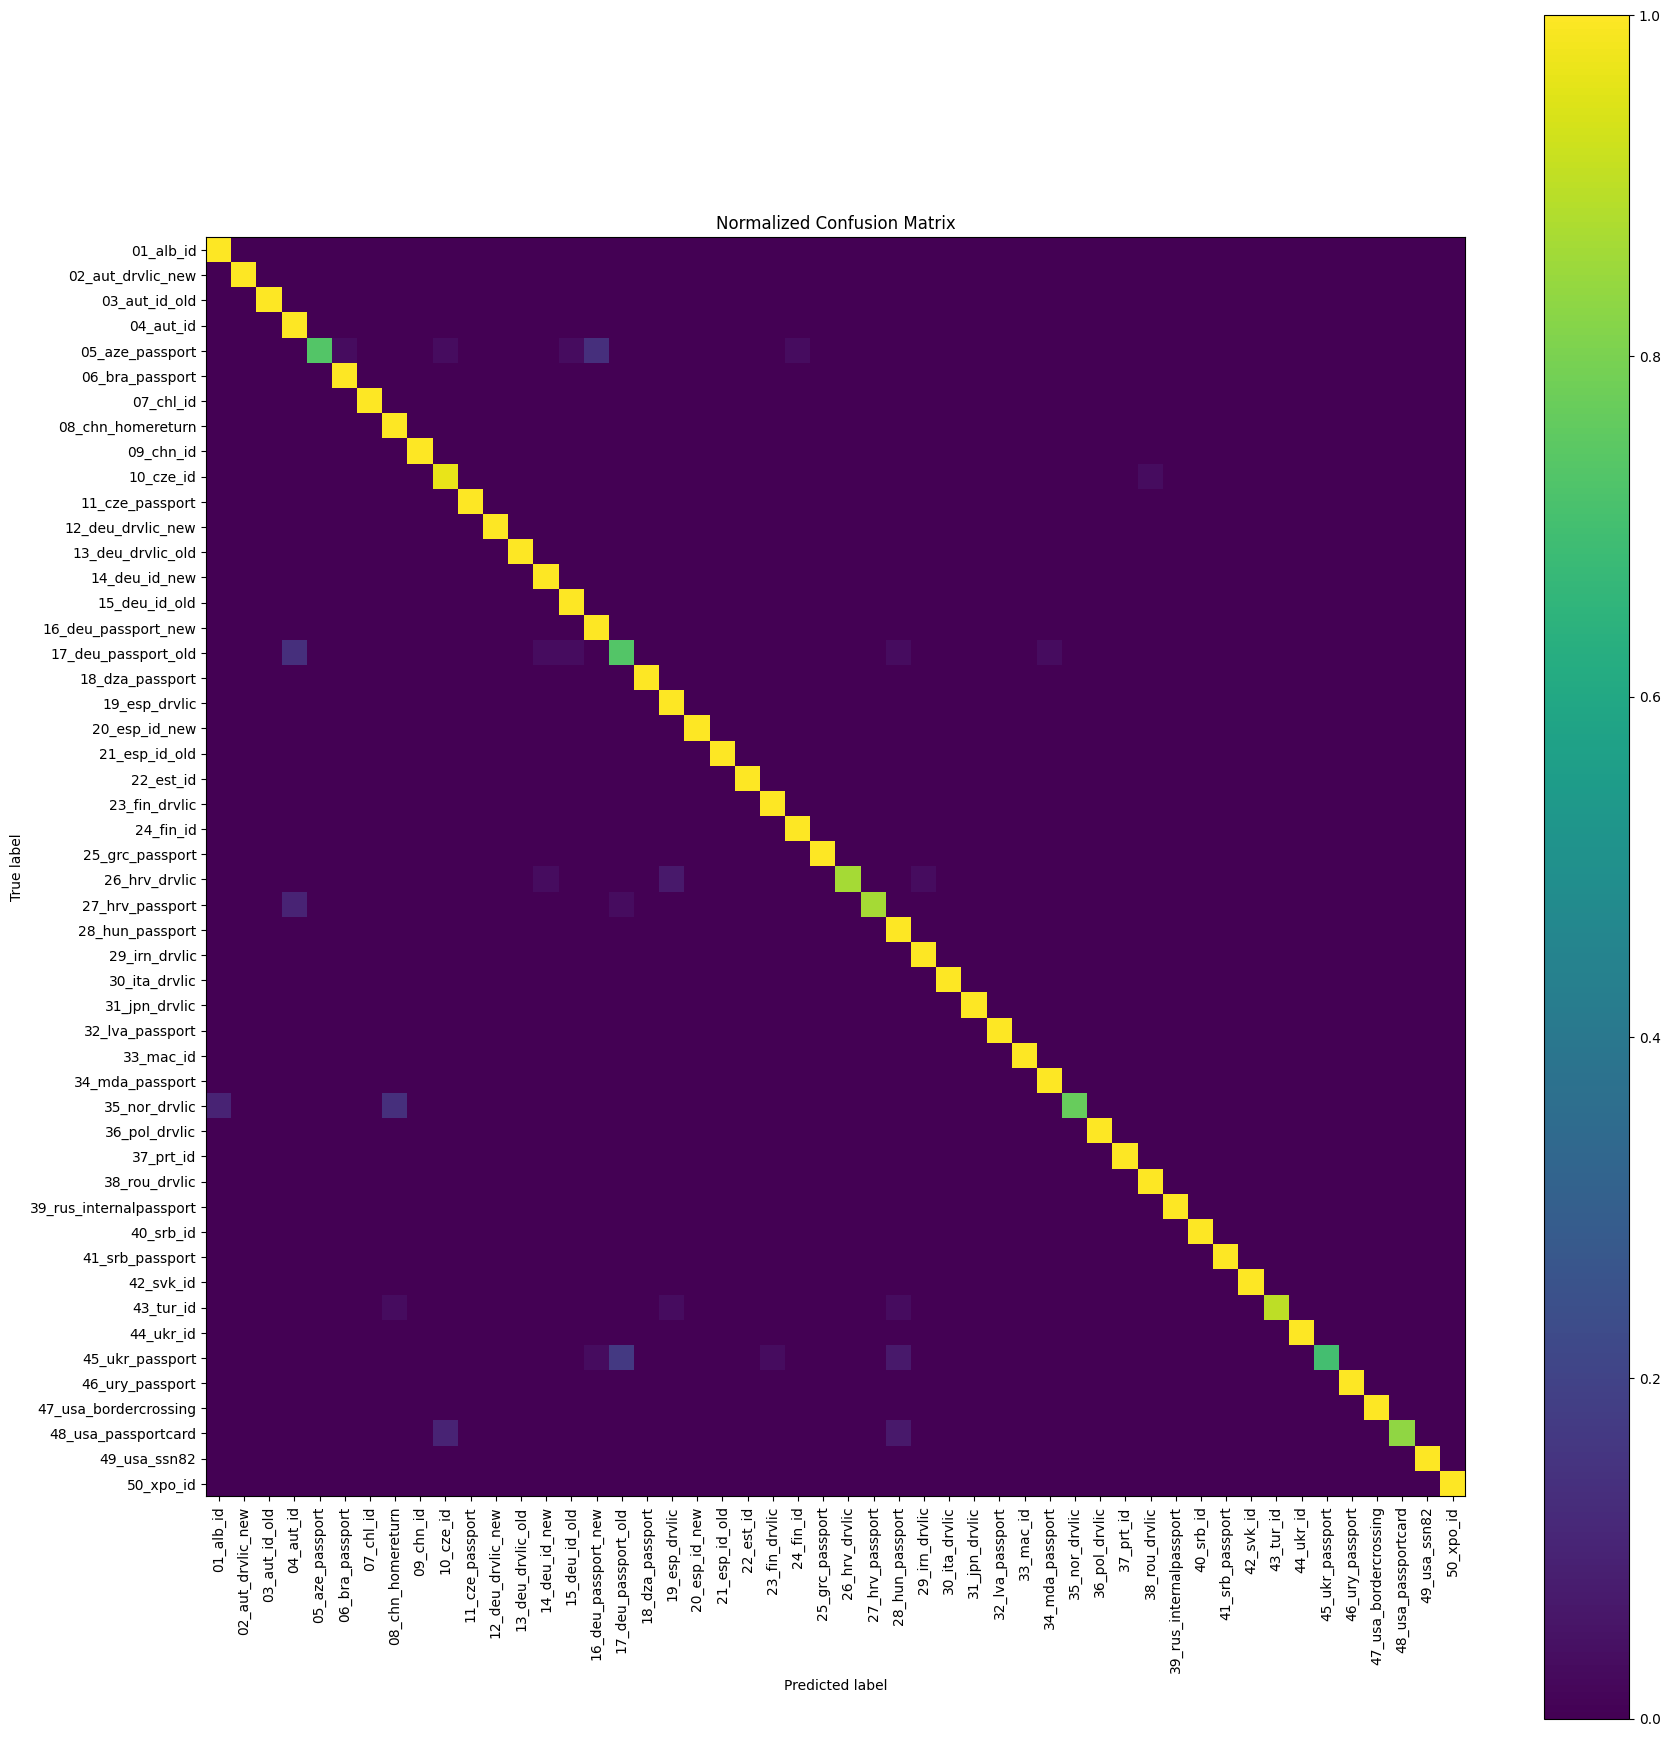

In [29]:
cm = confusion_matrix(all_labels, all_preds)

cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(18, 18))
plt.imshow(cm_normalized)
plt.colorbar()

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized Confusion Matrix")

class_names = list(class_to_idx.keys())

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.tight_layout()
plt.show()

In [ ]:
class_names = list(class_to_idx.keys())

cm = confusion_matrix(all_labels, all_preds)

confusions = []

for true_idx in range(len(class_names)):
    for pred_idx in range(len(class_names)):
        if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:

            confusions.append({
                "true": class_names[true_idx],
                "predicted": class_names[pred_idx],
                "errors": cm[true_idx, pred_idx]
            })

confusions = sorted(
    confusions,
    key=lambda x: x["errors"],
    reverse=True
)

for c in confusions[:20]:
    print(
        f"{c['true']:25s} -> "
        f"{c['predicted']:25s}: "
        f"{c['errors']} errori"
    )

45_ukr_passport           -> 17_deu_passport_old      : 5 errori
05_aze_passport           -> 16_deu_passport_new      : 4 errori
17_deu_passport_old       -> 04_aut_id                : 4 errori
35_nor_drvlic             -> 08_chn_homereturn        : 4 errori
27_hrv_passport           -> 04_aut_id                : 3 errori
35_nor_drvlic             -> 01_alb_id                : 3 errori
48_usa_passportcard       -> 10_cze_id                : 3 errori
26_hrv_drvlic             -> 19_esp_drvlic            : 2 errori
45_ukr_passport           -> 28_hun_passport          : 2 errori
48_usa_passportcard       -> 28_hun_passport          : 2 errori
05_aze_passport           -> 06_bra_passport          : 1 errori
05_aze_passport           -> 10_cze_id                : 1 errori
05_aze_passport           -> 15_deu_id_old            : 1 errori
05_aze_passport           -> 24_fin_id                : 1 errori
10_cze_id                 -> 38_rou_drvlic            : 1 errori
17_deu_passport_old      

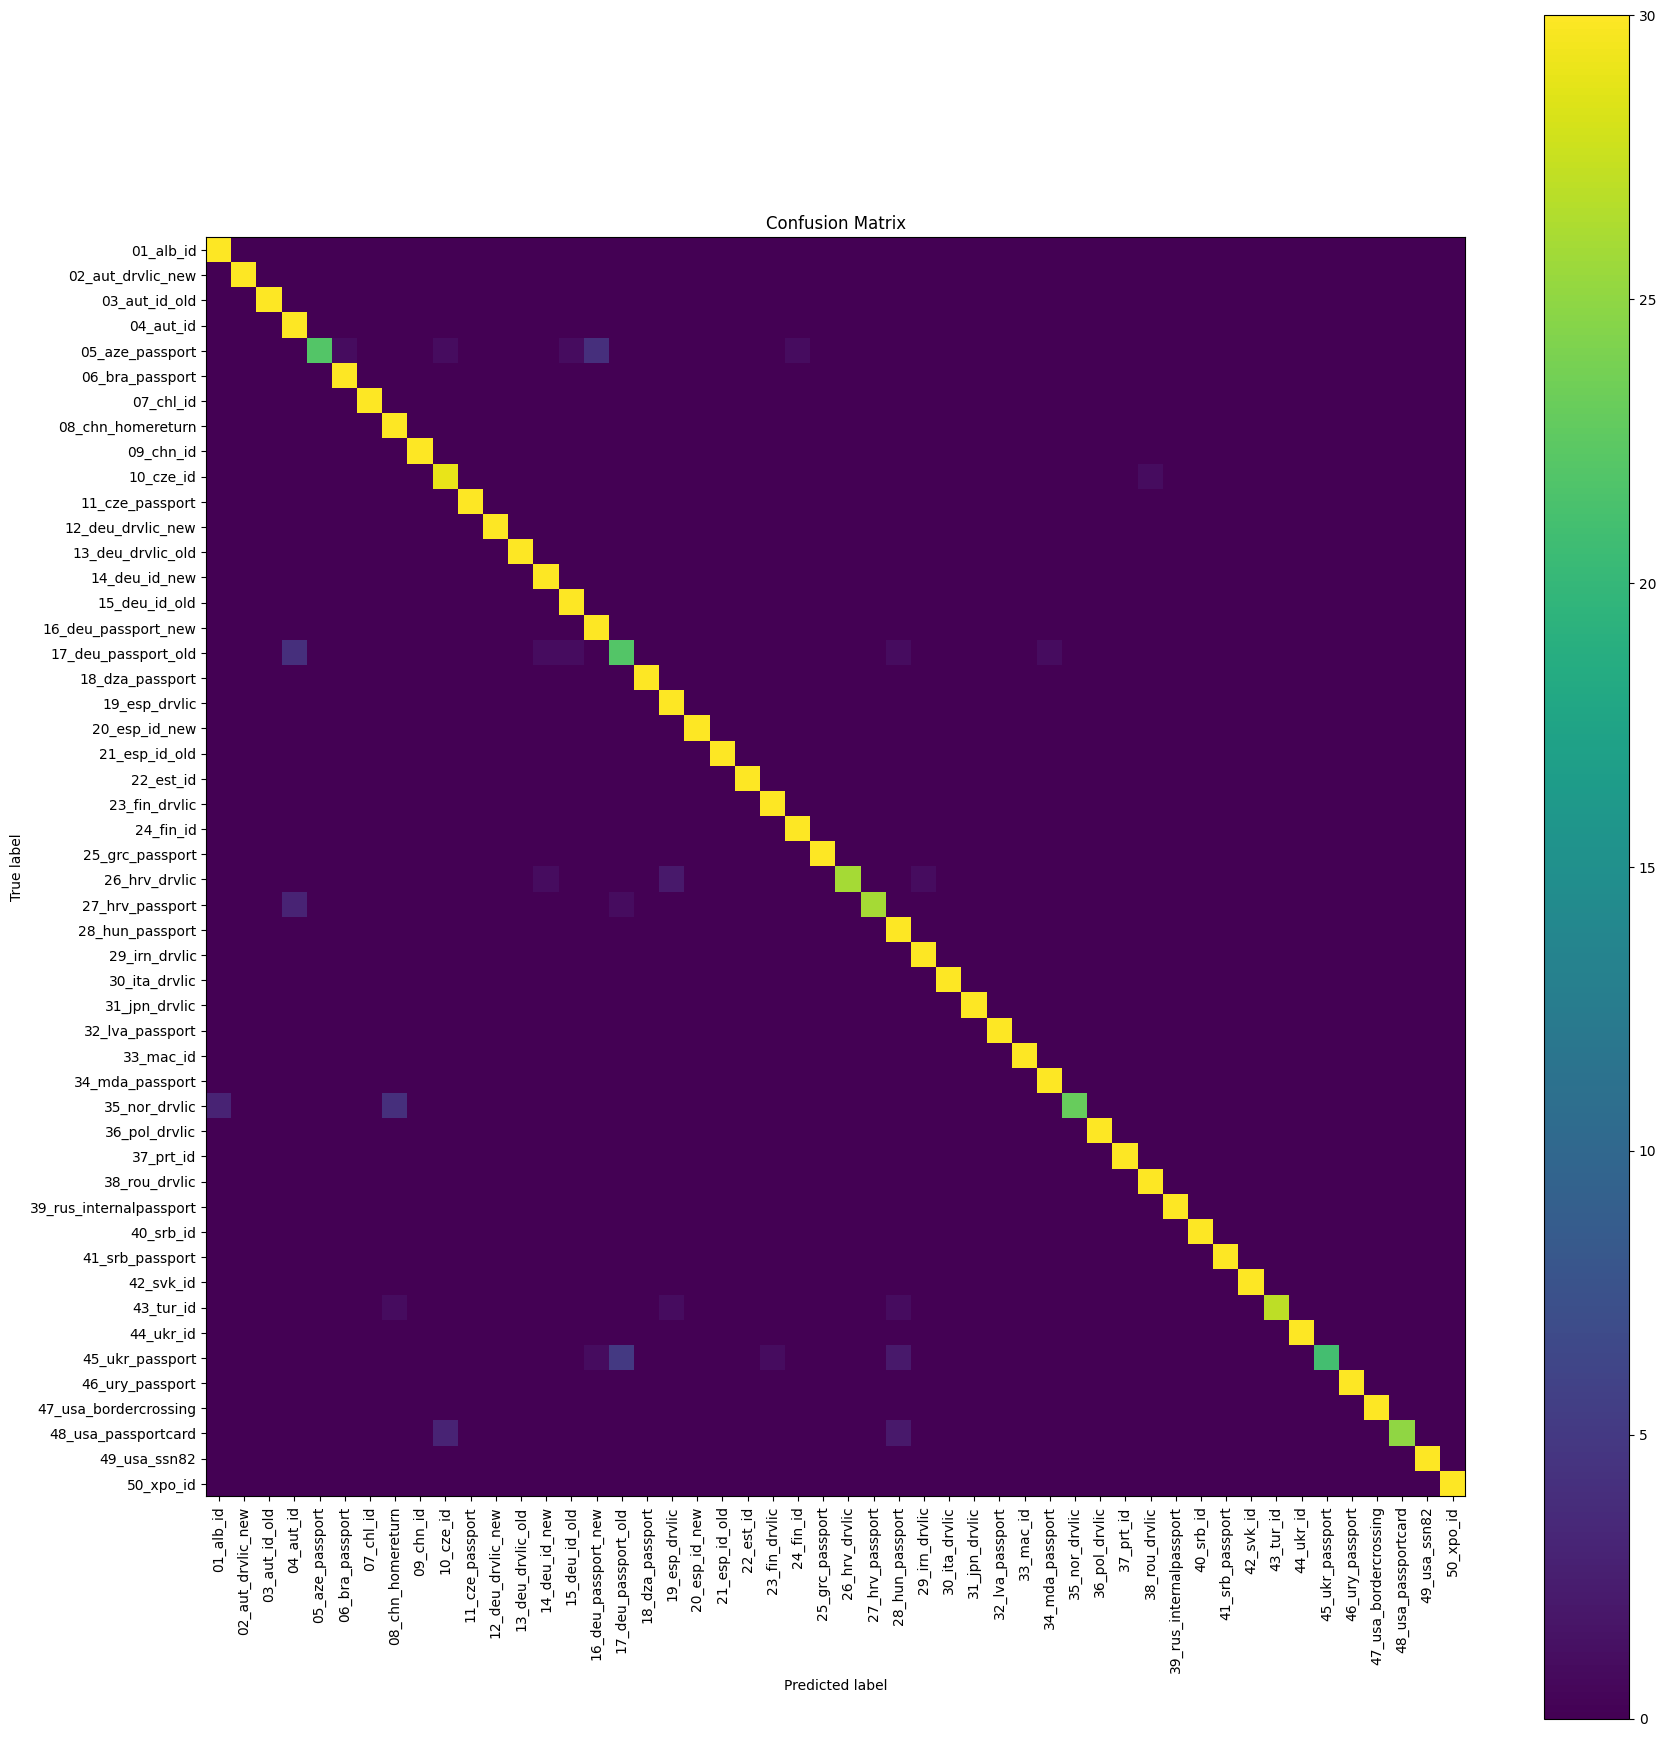

In [31]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(18, 18))
plt.imshow(cm)
plt.colorbar()

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.tight_layout()
plt.show()